In [1]:
"""
v9_long_term_memory.py
-------------------------
Personal Investment Research Assistant -- LONG-TERM MEMORY version.

Every previous version of this assistant (v7, v8) forgets everything the
moment a conversation (thread_id) ends. Ask it about your risk tolerance
in one thread, start a NEW thread, and it has no idea what you told it --
because the checkpointer (InMemorySaver, used in every earlier version) is
SCOPED TO ONE THREAD. That's correct behaviour for conversation history,
but wrong for things like "the user's risk tolerance" or "stocks the user
is watching" -- those should persist regardless of which conversation the
user starts.

That's what `Store` is for: a SEPARATE persistence system, keyed by
whatever namespace YOU choose (here, user_id) instead of thread_id. A
checkpointer and a store typically exist SIDE BY SIDE on the same
compiled graph -- one for thread-scoped conversation state, one for
cross-thread facts.

Pipeline, in plain English:

    1. LOAD PROFILE  -- before the LLM sees the user's message, this node
                        reads whatever is already saved in the Store for
                        THIS user_id (risk tolerance, watchlist) and turns
                        it into a short text summary.

    2. CALL MODEL     -- the LLM answers the user's message using that
                        profile summary as context, AND separately reports
                        (via structured output) whether the message
                        contains anything worth remembering long-term.
                        Same structured-output-with-manual-fallback pattern
                        used throughout the MT599 pipeline -- the same
                        provider-side reliability concerns apply here too.

    3. SAVE PROFILE   -- if the model detected a new risk tolerance or a
                        new watchlist addition, this node writes it into
                        the Store under this user_id's namespace. The NEXT
                        conversation -- even in a completely different
                        thread -- will see it via step 1.
"""

import os
import json
from enum import Enum
from typing import Optional, List, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA FOR THE MODEL'S RESPONSE
#    The model does TWO jobs in one call: answer the user, AND report
#    whether anything in the message is worth saving long-term. Structured
#    output keeps these two jobs cleanly separated instead of trying to
#    parse them back out of free text.
# ---------------------------------------------------------------------------

class RiskTolerance(str, Enum):
    conservative = "conservative"
    moderate = "moderate"
    aggressive = "aggressive"


class AssistantResponse(BaseModel):
    reply: str = Field(description="The natural-language answer to show the user.")
    detected_risk_tolerance: Optional[RiskTolerance] = Field(
        default=None,
        description="Set ONLY if the user's message explicitly states or implies a risk "
                    "tolerance (conservative/moderate/aggressive) that should be remembered. "
                    "Otherwise null.",
    )
    detected_watchlist_addition: Optional[str] = Field(
        default=None,
        description="A stock ticker ONLY if the user's message explicitly says they want to "
                    "watch/track/follow that stock. Otherwise null.",
    )



C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

structured_llm_json_schema = llm.with_structured_output(AssistantResponse, method="json_schema")


def _manual_json_extract(prompt: str) -> AssistantResponse:
    """
    DETERMINISTIC-FAILURE fallback -- same reasoning as the MT599 pipeline:
    Together AI's grammar compiler can reject certain schema shapes. Bypass
    it entirely by prompting for plain JSON and parsing/validating it
    ourselves.
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object matching this shape. "
        "Use the JSON keyword null (not the string \"null\") for any field "
        "that doesn't apply. Example:\n"
        '{"reply": "your answer here", "detected_risk_tolerance": null, '
        '"detected_watchlist_addition": null}\n'
        "Or with values filled in:\n"
        '{"reply": "your answer here", "detected_risk_tolerance": "conservative", '
        '"detected_watchlist_addition": "AAPL"}\n'
        "No markdown, no explanation -- just the JSON object."
    )
    raw_text = llm.invoke(manual_prompt).content.strip()
    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()
                                                                 

    data = json.loads(raw_text)

    # Defensive normalization: models sometimes write the STRING "null"
    # (or "none" / an empty string) instead of the JSON keyword null,
    # especially when a prompt example shows "null" as placeholder text
    # rather than an actual null value. Pydantic correctly rejects "null"
    # as an enum member (it isn't one) -- so we convert these look-alike
    # "empty" values back to real None ourselves, rather than trusting the
    # model's literal formatting.
    for key in ("detected_risk_tolerance", "detected_watchlist_addition"):
        if isinstance(data.get(key), str) and data[key].strip().lower() in ("null", "none", ""):
            data[key] = None

    return AssistantResponse.model_validate(data)





In [3]:

# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

RESPONSE_PROMPT = """You are a personal investment research assistant with long-term memory
about this specific user.

What you already know about this user:
{profile_context}

User's new message:
"{user_message}"

Answer the user's message, using what you already know about them where relevant.
Separately, determine whether THIS message reveals a NEW risk tolerance or a NEW
stock to add to their watchlist -- only report these if explicitly stated in this
message, don't repeat something you already knew from before.
"""


In [4]:

# ---------------------------------------------------------------------------
# 4. GRAPH STATE
# ---------------------------------------------------------------------------

class ProfileState(TypedDict):
    user_id: str          # the cross-thread identity Store entries are keyed on
    user_message: str
    profile_context: str  # human-readable summary of what's already saved
    assistant_reply: str
    detected_risk_tolerance: Optional[str]
    detected_watchlist_addition: Optional[str]


In [5]:

# ---------------------------------------------------------------------------
# 5. NODE: load_profile
#    `store: BaseStore` is a KEYWORD-ONLY parameter -- LangGraph detects
#    this signature and automatically injects whatever store object was
#    passed to compile(store=...), the same way it injects `config` for
#    nodes that declare it. This node runs FIRST, before the LLM even sees
#    the message.
#
#    Namespace choice: (user_id, "profile") -- NOT thread_id. This is the
#    entire mechanism that makes memory survive across different
#    conversations: two different thread_ids with the SAME user_id read
#    and write the exact same namespace.
# ---------------------------------------------------------------------------

def load_profile(state: ProfileState, *, store: BaseStore) -> dict:
    namespace = (state["user_id"], "profile")
    existing = store.get(namespace, "data")

    if existing is None:
        profile_context = "Nothing saved yet -- this appears to be a new user."
    else:
        data = existing.value
        risk = data.get("risk_tolerance", "not yet known")
        watchlist = data.get("watchlist", [])
        watchlist_str = ", ".join(watchlist) if watchlist else "empty"
        profile_context = f"Risk tolerance: {risk}. Watchlist: {watchlist_str}."

    return {"profile_context": profile_context}



In [6]:
# ---------------------------------------------------------------------------
# 6. NODE: call_model
#    Ordinary LLM call -- no store access here. Structured output +
#    manual fallback, same pattern as the MT599 pipeline's
#    extract_instructions node.
# ---------------------------------------------------------------------------

def call_model(state: ProfileState) -> dict:
    prompt = RESPONSE_PROMPT.format(
        profile_context=state["profile_context"],
        user_message=state["user_message"],
    )
    try:
        result = structured_llm_json_schema.invoke(prompt)
    except (ValidationError, json.JSONDecodeError) as first_error:
        try:
            result = _manual_json_extract(prompt)
        except Exception as second_error:
            # Both the preferred AND fallback paths failed -- degrade
            # gracefully instead of crashing the whole graph. The user
            # still gets a plain-text answer; we just skip the
            # memory-detection step for this one turn rather than losing
            # the conversation entirely.
            result = AssistantResponse(
                reply=llm.invoke(state["user_message"]).content,
                detected_risk_tolerance=None,
                detected_watchlist_addition=None,
            )
    except Exception as e:
        if "grammar" in str(e).lower() or "schema" in str(e).lower():
            try:
                result = _manual_json_extract(prompt)
            except Exception:
                result = AssistantResponse(
                    reply=llm.invoke(state["user_message"]).content,
                    detected_risk_tolerance=None,
                    detected_watchlist_addition=None,
                )
        else:
            raise

    return {
        "assistant_reply": result.reply,
        "detected_risk_tolerance": result.detected_risk_tolerance.value if result.detected_risk_tolerance else None,
        "detected_watchlist_addition": result.detected_watchlist_addition,
    }



In [7]:

# ---------------------------------------------------------------------------
# 7. NODE: save_profile
#    Also gets `store` injected. Only writes if the model actually detected
#    something new -- a message that's purely a question ("what's my risk
#    tolerance?") shouldn't overwrite anything.
#
#    store.put(namespace, key, value) -- value is a plain dict, stored as
#    one JSON-serializable blob under that key. Reading it back later (see
#    load_profile above) is a plain store.get(namespace, key).
# ---------------------------------------------------------------------------

def save_profile(state: ProfileState, *, store: BaseStore) -> dict:
    if not state.get("detected_risk_tolerance") and not state.get("detected_watchlist_addition"):
        return {}  # nothing new to save

    namespace = (state["user_id"], "profile")
    existing = store.get(namespace, "data")
    profile = dict(existing.value) if existing else {"risk_tolerance": None, "watchlist": []}

    if state.get("detected_risk_tolerance"):
        profile["risk_tolerance"] = state["detected_risk_tolerance"]

    if state.get("detected_watchlist_addition"):
        ticker = state["detected_watchlist_addition"].upper()
        if ticker not in profile["watchlist"]:
            profile["watchlist"].append(ticker)

    store.put(namespace, "data", profile)
    return {}


In [8]:

# ---------------------------------------------------------------------------
# 8. BUILD THE GRAPH
#    Both a checkpointer AND a store are passed to compile() -- they serve
#    DIFFERENT purposes and neither replaces the other:
#      - checkpointer (InMemorySaver): per-thread conversation state.
#        A fresh thread_id starts with NO history, by design.
#      - store (InMemoryStore): cross-thread facts about a user_id.
#        A fresh thread_id with the SAME user_id still sees everything
#        saved here.
# ---------------------------------------------------------------------------

builder = StateGraph(ProfileState)
builder.add_node("load_profile", load_profile)
builder.add_node("call_model", call_model)
builder.add_node("save_profile", save_profile)

builder.add_edge(START, "load_profile")
builder.add_edge("load_profile", "call_model")
builder.add_edge("call_model", "save_profile")
builder.add_edge("save_profile", END)

checkpointer = InMemorySaver()
store = InMemoryStore()
graph = builder.compile(checkpointer=checkpointer, store=store)



In [9]:

# ---------------------------------------------------------------------------
# 9. VISUALIZE THE GRAPH
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v9.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")



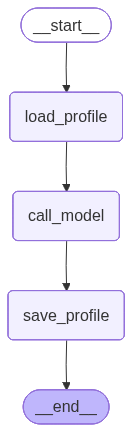


SESSION A -- alice, thread 'alice-session-1' (first ever message)
Assistant: Thank you for letting me know your interest in AAPL, as a conservative investor. I'll keep an eye on AAPL for you and provide regular updates on its performance and any relevant news. If you have any specific questions or need advice on how to incorporate AAPL into your portfolio, feel free to ask.

SESSION B -- alice, thread 'alice-session-2' (BRAND NEW thread)
Assistant: Your risk tolerance is conservative and you have AAPL on your watchlist.
(This should already reflect Session A's info -- proving Store, not the checkpointer, is what carried it over.)

SESSION C -- bob, thread 'bob-session-1' (different USER entirely)
Assistant: Hello! It seems like this is your first interaction with me, so I don't have any information about your risk tolerance or watchlist yet. Could you provide me with more details about your investment preferences or any stocks you're interested in following?
(This should know NOTHING 

In [10]:

# ---------------------------------------------------------------------------
# 10. QUICK TEST -- proves memory survives across DIFFERENT threads for the
#     SAME user, and does NOT leak between DIFFERENT users.
#
#     Session A: user "alice", thread "alice-session-1"
#         -> tells the assistant her risk tolerance and a stock to watch
#     Session B: user "alice", thread "alice-session-2"  (DIFFERENT THREAD)
#         -> asks what the assistant knows about her -- should already
#            know, despite this being a brand-new thread with zero
#            checkpointer history
#     Session C: user "bob", thread "bob-session-1"  (DIFFERENT USER)
#         -> asks the same question -- should know NOTHING about bob,
#            proving alice's data didn't leak into bob's namespace
# ---------------------------------------------------------------------------

def send(user_id: str, thread_id: str, message: str) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "user_id": user_id,
        "user_message": message,
        "profile_context": "",
        "assistant_reply": "",
        "detected_risk_tolerance": None,
        "detected_watchlist_addition": None,
    }
    return graph.invoke(initial_state, config)


if __name__ == "__main__":
    visualize_graph(graph)

    print("\n" + "=" * 70)
    print("SESSION A -- alice, thread 'alice-session-1' (first ever message)")
    print("=" * 70)
    result_a = send(
        user_id="alice",
        thread_id="alice-session-1",
        message="I'm a conservative investor and I'd like to keep an eye on AAPL.",
    )
    print(f"Assistant: {result_a['assistant_reply']}")

    print("\n" + "=" * 70)
    print("SESSION B -- alice, thread 'alice-session-2' (BRAND NEW thread)")
    print("=" * 70)
    result_b = send(
        user_id="alice",
        thread_id="alice-session-2",  # different thread -- no checkpointer history at all
        message="What do you know about my risk tolerance and watchlist?",
    )
    print(f"Assistant: {result_b['assistant_reply']}")
    print("(This should already reflect Session A's info -- proving Store, "
          "not the checkpointer, is what carried it over.)")

    print("\n" + "=" * 70)
    print("SESSION C -- bob, thread 'bob-session-1' (different USER entirely)")
    print("=" * 70)
    result_c = send(
        user_id="bob",
        thread_id="bob-session-1",
        message="What do you know about my risk tolerance and watchlist?",
    )
    print(f"Assistant: {result_c['assistant_reply']}")
    print("(This should know NOTHING -- proving alice's data is namespaced "
          "away from bob's, not shared globally.)")
